# MODELO DETECTOR DE FIGURAS GEOMÉTRICAS APLICANDO REDES NEURONALES CONVOLUCIONALES (CNN)


## HECHO POR MARÍA JUÁREZ MOLERA, DAMIÁN PÉREZ MORENO, SAHAR AMANMOHAMMADI, ÍKER ÁLAMO GÓMEZ DE SEGURA Y RUBÉN LAGO LÓPEZ

# Contexto e Introducción

En nuestro proyecto de redes neuronales, hemos utilizado el dataset y el notebook de Nguyễn Minh Đức (nombre del creador) disponible en este enlace: https://www.kaggle.com/code/dukiee/nh-m-13  como base para la implementación. 


Acerca de este directorio:

Este conjunto de datos está compuesto por 3 formas geométricas (Triángulo, Cuadrado y Círculo), cada una de las cuales se dibuja de manera aleatoria en una imagen RGB de 200 x 200 píxeles. Durante la generación de este conjunto de datos, el perímetro y la posición de cada forma se seleccionan de manera aleatoria e independiente para cada imagen. El ángulo de rotación de cada forma también se selecciona de forma aleatoria dentro de un intervalo entre 0° y 360°. Asimismo, el color de fondo de cada imagen y el color de relleno de cada forma se eligen de manera aleatoria e independiente.

El conjunto de datos está compuesto por 3 clases de datos; cada clase representa un tipo de forma geométrica (Triángulo, Cuadrado y Círculo) y cada una de ellas está compuesta por 10 000 imágenes generadas. Todas las imágenes se guardan en carpetas individuales ( Circle, Square, Triangle) dentro de la carpeta que las engloba llamada dataset, situada en la raíz del proyecto.


Por otro lado, hemos modificado el código original del notebook, que hacía uso de una red preentrenada ResNet50 para clasificar imágenes en tres categorías geométricas (círculo, triángulo y cuadrado). En lugar de utilizar ResNet50, optamos por implementar una red neuronal convolucional (CNN) personalizada, ya que era una de las arquitecturas que debíamos investigar en el marco del proyecto.

La red preentrenada ResNet50, utilizada en el notebook original, es una arquitectura de redes residuales con 50 capas, preentrenada en el conjunto de datos ImageNet. ResNet50 se caracteriza por su capacidad para aprender características complejas gracias a su profundidad y a los bloques residuales, que resuelven el problema de la degradación en redes profundas al facilitar el flujo del gradiente mediante conexiones de salto.

En nuestro caso, elegimos desarrollar una red neuronal convolucional (CNN) desde cero. Las CNN son arquitecturas específicas para el procesamiento de datos estructurados espacialmente, como las imágenes, y están compuestas por capas convolucionales que extraen características relevantes, capas de pooling para reducir la dimensionalidad, y capas densas para realizar la clasificación. Este enfoque nos permitió profundizar en el funcionamiento interno de las redes convolucionales, comprendiendo cómo se entrenan y cómo extraen características directamente del conjunto de datos. Además, este cambio nos permitió cumplir con los requisitos del proyecto, que requería explorar el diseño y la implementación de una red neuronal convolucional personalizada.

Con este enfoque, conseguimos adaptar el modelo para realizar la tarea de clasificación geométrica manteniendo buenos resultados de precisión y comprendiendo mejor las ventajas y limitaciones de las redes neuronales convolucionales.

# Explicación básica del funcionamiento de una Red Neuronal Convolucional
Objetivo: A partir de fotos, obtener patrones, reglas y características de interés para poder diferenciar imágenes y clasificarlas.

¿Cómo se hace?: Cada píxel de la imagen pasa como parámetro de entrada en la red neuronal.Cada valor del pixel esta asociado con la característica de dicha parte de la imagen ( brillo, color, saturación, sombra, etc)

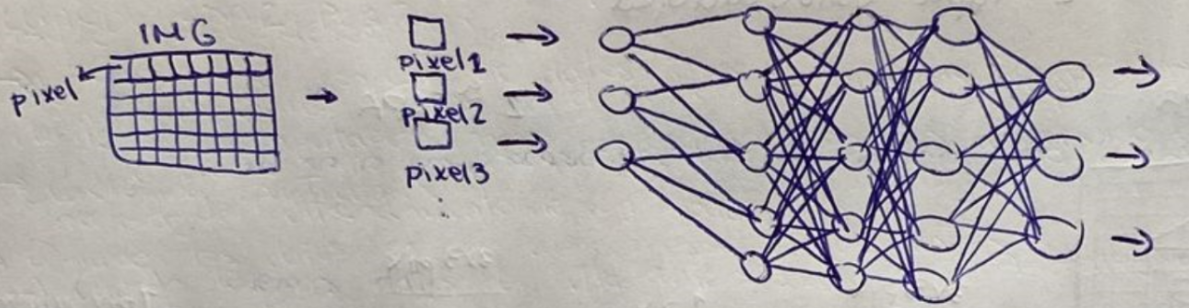

La red neuronal convolucional tiene una capa donde se realiza un cálculo matemático llamado CONVOLUCIÓN (operación que juega con los valores de los píxeles para generar píxeles nuevos). Esto se hace estableciendo una matriz llamada FILTRO o KERNEL sobre la imagen original y donde se sumarán y multiplicarán los valores de cada píxel de la matriz para obtener el valor del nuevo píxel. Luego se irá desplazando esa matriz por el resto de la imagen para ir calculando el resto de píxeles nuevos para obtener como resultado una imagen que resalta solo los patrones que el filtro encontró y le servirán al algoritmo que estamos codificando como modelo de referencia para determinar si la imagen pertenece a una clase u otra. Esta nueva imagen se llama MAPA DE CARACTERÍSTICAS.

Depende de los valores del filtro que establezcamos, este detectará en la imagen unas características u otras, pero estos valores de la matriz los va a ir aprendiendo la red neuronal poco a poco a medida que se le van pasando las imágenes del dataset con el objetivo de aprender cómo configurar los filtros de la mejor forma y poder así averiguar patrones.

El mapa de características actúa como un mapa donde se nos indica en qué parte de la imagen se ha detectado la característica buscada por el filtro.
La operación de convolución se va a realizar de manera secuencial donde el output de una de las capas se va a convertir en el input de la siguiente. La operación de convolución por sí sola no puede detectar mucho más que bordes y patrones simples, pero volver a hacer detecciones sobre las detecciones anteriores nos permite componer cada vez patrones más complejos.

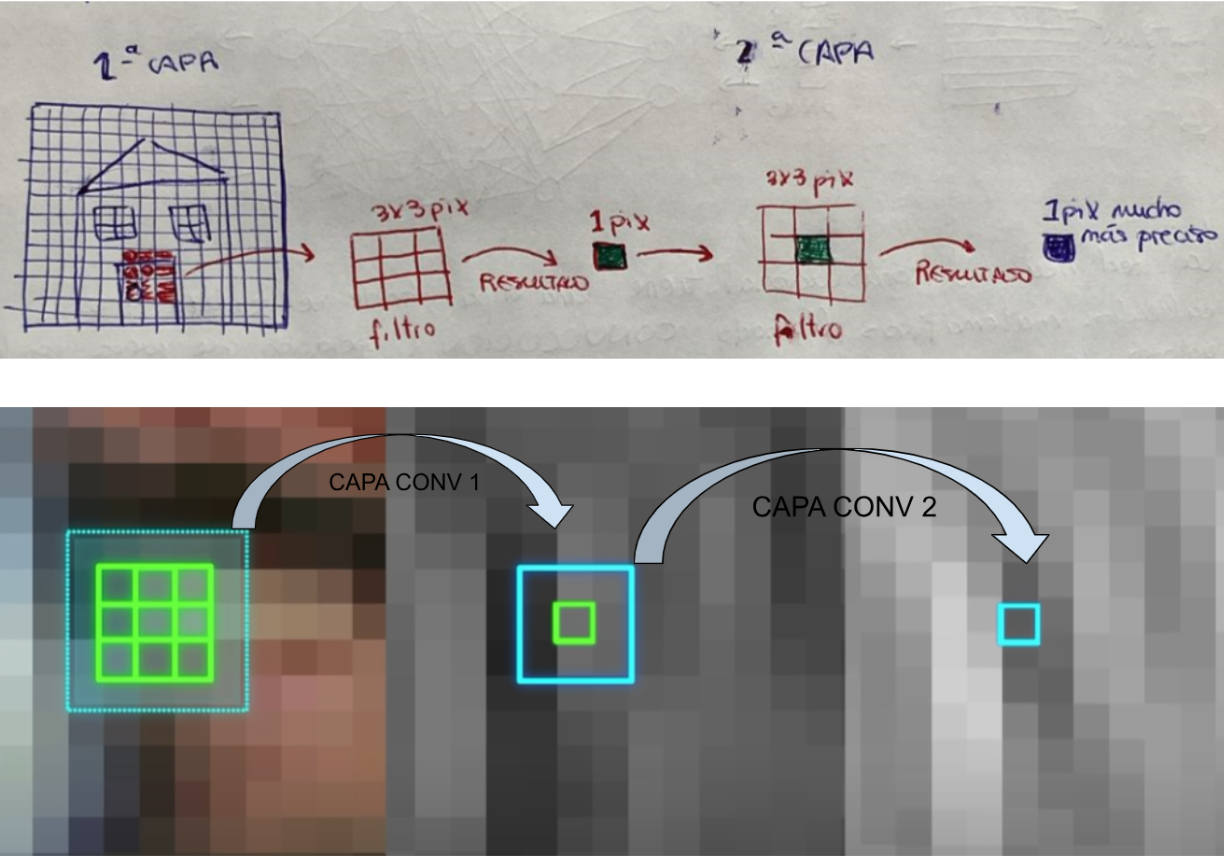

Ejemplo:
Si tenemos una imagen de entrada y en la 1ª capa convolucional le aplicamos un filtro (kernel) de un valor de 16, es decir, en la operación de convolución determinamos que vamos a aplicar 16 filtros, detectaremos 16 cosas diferentes y obtendremos como resultado 16 mapas de características (16 imágenes), las cuales se van a convertir en el input de la 2ª capa convolucional.

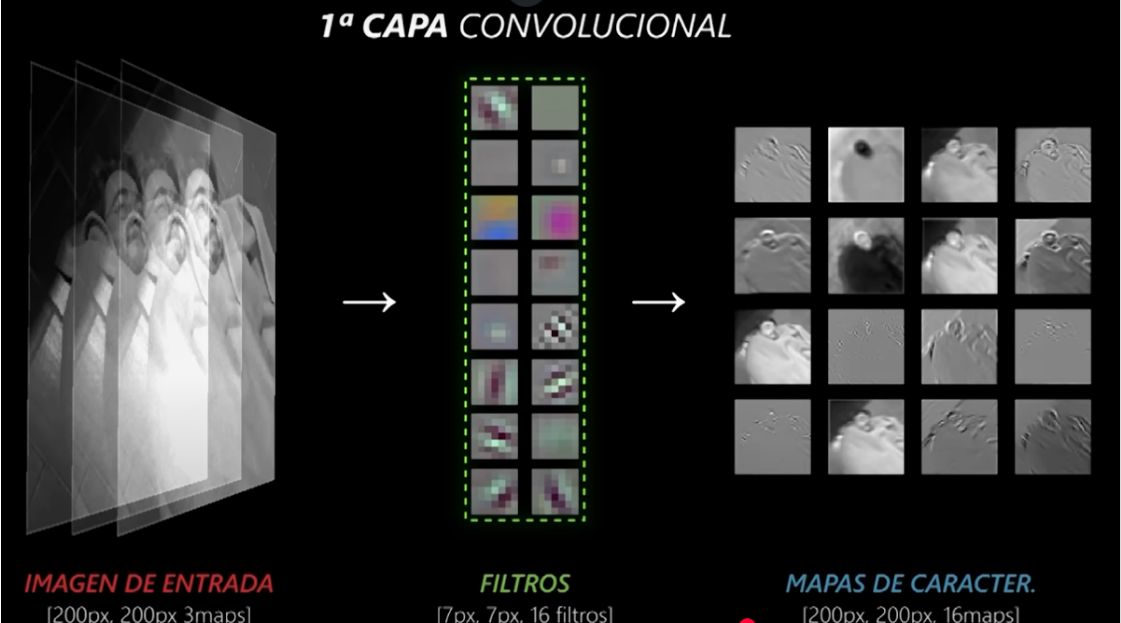


IMAGEN DE ENTRADA:
200px,200px → es el tamaño de la imagen de entrada (200px X 200px)
3map → hace referencia a las capas ( RED, GREEN, BLUE) que tiene una foto a color

FILTROS:
7px, 7px → es el tamaño de la matriz del filtro
16 → indica el número de matrices que se van a aplicar

MAPA DE CARACTERISTICAS:
200px, 200px → es el tamaño de la imagen resultado  (200px X 200px)
16 maps → indica el numero de mapas de caracteristicas que se han generado, uno por cada filtro aplicado


Por qué usar varias capas de filtros

Primera capa: Detecta cosas simples como bordes y líneas.
Segunda capa: Usa las pistas de la primera capa para detectar cosas más complejas, como círculos o esquinas.
Capas más profundas: Combina todo lo aprendido para detectar formas específicas, como una cara, una oreja o incluso un objeto completo.

En nuestro proyecto, al tener como OUTPUT que las imágenes pueden ser un circulo, un triangulo o un cuadrado, la capa de salida de la red neuronal tendrá un total de 3 neuronas y en cada una de ellas aparecerá un porcentaje de pertenencia a ser circulo, triangulo o cuadrado dependiendo de cómo las capas han tratado los pixeles que conforman la imagen que se ha tomado para ser analizada

Por ejemplo:
Si tienes una imagen de 28x28 píxeles la primera capa de la red tendrá 28 × 28 = 784 neuronas.
Cada una de esas neuronas toma el valor del brillo o color del píxel correspondiente en la imagen.

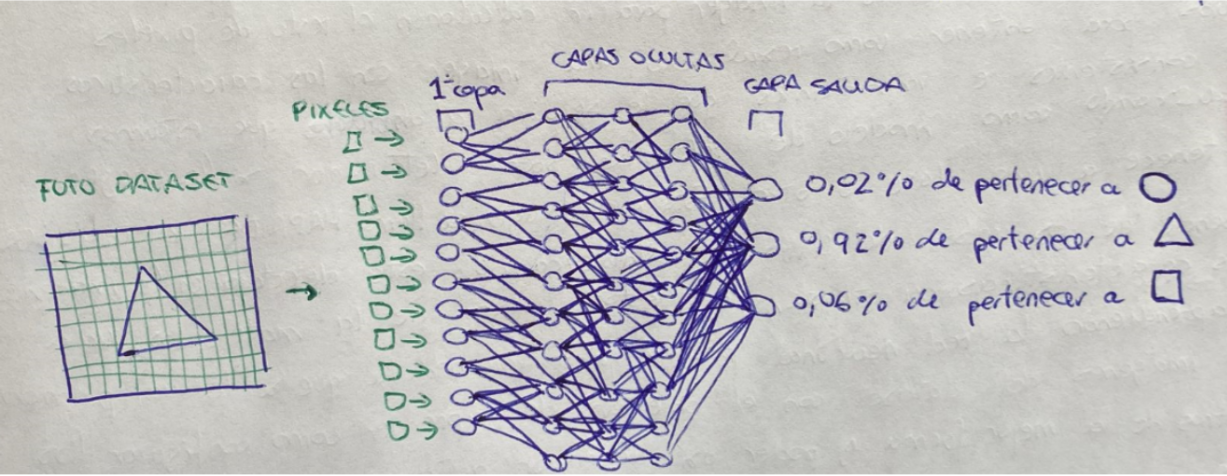




# Proceso y pasos a seguir para realizar el modelo

1. Definir el problema

- Objetivo: Clasificar imágenes en tres clases: círculo, triángulo, cuadrado.
- Datos disponibles: Imágenes de figuras organizadas en carpetas según su clase.
- Formato de entrada: Imágenes en color (RGB) de tamaño variable.
- Formato de salida: Una predicción que indique la clase de la imagen.


2. Recolectar y preparar los datos (Este es uno de los pasos más importantes).
a. Recolectar datos : Las imágenes deben estar organizadas en carpetas según su clase
b. Preprocesar los datos:

- Organizar las rutas de las imágenes: Usamos un script para recorrer las carpetas y obtener las rutas de las imágenes con sus etiquetas correspondientes.
- One-hot encoding de las etiquetas: Convertimos las etiquetas ("circle", "square", "triangle") en vectores binarios. Ejemplo:
circle → [1, 0, 0]
square → [0, 1, 0]
triangle → [0, 0, 1]

- Dividir los datos: Dividimos el conjunto de datos en:
Entrenamiento (70%): Para entrenar el modelo
Validación (15%): Para evaluar el rendimiento durante el entrenamiento
Prueba (15%): Para medir el rendimiento final del modelo.

- Normalizar las imágenes: Dividimos los valores de los píxeles por 255 para llevarlos al rango [0, 1].
- Redimensionar las imágenes: Aseguramos que todas las imágenes tengan el mismo tamaño, por ejemplo, 224x224 píxeles.

3. Crear generadores de datos
En lugar de cargar todas las imágenes en memoria, usamos generadores para procesarlas en pequeños lotes con un Generador para entrenamiento, otro para la validacion y otro para la prueba.

4. Diseñar la arquitectura del modelo
Aquí es donde construimos la CNN. Los pasos básicos son:

a. Elegir una arquitectura inicial: Para un problema sencillo como el que tenemos:

- Capas convolucionales (Conv2D): Extraen características como bordes, esquinas y formas de las imágenes. Cada capa añade más filtros para capturar patrones más complejos.
- Capas de pooling (MaxPooling2D): Reducen las dimensiones espaciales para disminuir la carga computacional.
- Capa de aplanamiento (Flatten): Convierte las características 2D en un vector 1D.
- Capas densas (Dense): Combinan las características aprendidas y generan la predicción final.
- Dropout: Evita el sobreajuste desactivando aleatoriamente conexiones entre las neuronas.

b. Compilar el modelo

- Optimizador: Por ejemplo, Adam con una tasa de aprendizaje inicial de 0.001.
- Función de pérdida: categorical_crossentropy (porque tenemos varias clases).
- Métrica: accuracy para medir la precisión del modelo.

5. Entrenar el modelo
Usamos los generadores de datos para entrenar el modelo.

a. Callbacks
EarlyStopping: Detiene el entrenamiento si la pérdida de validación no mejora después de varias épocas.
ModelCheckpoint: Guarda los pesos del mejor modelo durante el entrenamiento.
b. Entrenar

6. Evaluar el modelo
Después de entrenar, evaluamos el modelo en el conjunto de prueba para medir su rendimiento final

7. Analizar las métricas de rendimiento
- Precisión (accuracy): ¿Qué tan bien clasifica el modelo las imágenes?
- Pérdida (loss): ¿Qué tan lejos están las predicciones del modelo de las verdaderas etiquetas? Medida de qué tan mal está funcionando el modelo al hacer predicciones. En otras palabras, es un número que representa el error entre lo que la red predice y lo que debería haber predicho (es decir, la verdad).

8. Visualizar los resultados
Graficamos las curvas de pérdida y precisión para analizar el rendimiento del modelo

9. Realizar predicciones
Usamos el modelo entrenado para clasificar nuevas imágenes

In [1]:
import numpy as np  # Álgebra lineal
import pandas as pd  # Procesamiento de datos, lectura/escritura de archivos CSV
from tensorflow import keras  # Importar Keras desde TensorFlow
import matplotlib.pyplot as plt
import os
import sklearn
import random

# Ruta base de la carpeta que contiene las figuras
base_dir = './dataset'  

# Lista para almacenar las rutas de los archivos
dir_names = []

# Recorrer la carpeta "dataset" y sus subcarpetas
for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        # Generar la ruta completa del archivo
        dir_name = os.path.join(dirname, filename)
        dir_names.append(dir_name)

# Imprimir la cantidad total de archivos encontrados
print(f"Total de archivos encontrados: {len(dir_names)}")

# imprimir las primeras rutas encontradas para verificar
print("Ejemplos de rutas de archivos:")
print(dir_names[:5])


Total de archivos encontrados: 29970
Ejemplos de rutas de archivos:
['./dataset\\Circle\\Circle_000dfc5c-2a92-11ea-8123-8363a7ec19e6.png', './dataset\\Circle\\Circle_000ed2d8-2a8a-11ea-8123-8363a7ec19e6.png', './dataset\\Circle\\Circle_0013f29e-2a9a-11ea-8123-8363a7ec19e6.png', './dataset\\Circle\\Circle_001d7284-2a85-11ea-8123-8363a7ec19e6.png', './dataset\\Circle\\Circle_001de166-2a89-11ea-8123-8363a7ec19e6.png']


Se importan bibliotecas esenciales:
- numpy y pandas: Para el manejo de datos numéricos y tabulares.
- matplotlib.pyplot: Para la visualización de datos.
- tensorflow.keras: Para trabajar con redes neuronales.
- os: Para manejar rutas de archivos y carpetas.
- sklearn y random: Para tareas adicionales relacionadas con aprendizaje automático y generación de valores aleatorios.

Se define la variable base_dir que apunta al directorio base llamado ./dataset. Este directorio contiene subcarpetas para cada clase (círculo, cuadrado, triángulo), y dentro de estas subcarpetas están las imágenes.

Usando os.walk, el código recorre recursivamente la carpeta dataset y sus subcarpetas.
Por cada archivo encontrado se genera su ruta completa combinando el directorio (dirname) y el nombre del archivo (filename). Esta ruta se agrega a la lista dir_names.

Finalmente se imprime la cantidad total de archivos encontrados en la carpeta dataset y se muestran las primeras 5 rutas completas encontradas en dir_names para verificar que los archivos han sido localizados correctamente.

# Data to Dataframe

In [2]:
# Lista para almacenar rutas y etiquetas
paths = []
labels = []

for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        # Ruta completa del archivo
        file_path = os.path.join(dirname, filename)
        paths.append(file_path)

        # Extraer la etiqueta del nombre de la carpeta
        label = os.path.basename(dirname).lower()  # Nombre de la subcarpeta
        labels.append(label)

# Crear un DataFrame con rutas y etiquetas
data_frame = pd.DataFrame({'path': paths, 'label': labels})

# Verificar el contenido del DataFrame
print(data_frame.head())


                                                path   label
0  ./dataset\Circle\Circle_000dfc5c-2a92-11ea-812...  circle
1  ./dataset\Circle\Circle_000ed2d8-2a8a-11ea-812...  circle
2  ./dataset\Circle\Circle_0013f29e-2a9a-11ea-812...  circle
3  ./dataset\Circle\Circle_001d7284-2a85-11ea-812...  circle
4  ./dataset\Circle\Circle_001de166-2a89-11ea-812...  circle


Se crean dos listas: paths y labels.
Se itera sobre las rutas de los archivos en dir_names.
De cada ruta, se extrae el penúltimo elemento del nombre  (que corresponde a la etiqueta) y se guarda en la lista labels.
Las rutas completas de los archivos se almacenan en paths.

In [3]:
# Crear un DataFrame con las rutas y etiquetas
data_frame = pd.DataFrame()
data_frame['path'] = paths # Columna con las rutas de los archivos
data_frame['label'] = labels # Columna con las etiquetas


Se crea un DataFrame usando pandas para organizar las rutas y etiquetas en una estructura tabular.

La columna path contiene las rutas de los archivos, y label contiene las etiquetas.

In [4]:
data_frame # Mostrar el DataFrame resultante

,path,label
0,./dataset\Circle\Circle_000dfc5c-2a92-11ea-812...,circle
1,./dataset\Circle\Circle_000ed2d8-2a8a-11ea-812...,circle
2,./dataset\Circle\Circle_0013f29e-2a9a-11ea-812...,circle
3,./dataset\Circle\Circle_001d7284-2a85-11ea-812...,circle
4,./dataset\Circle\Circle_001de166-2a89-11ea-812...,circle
...,...,...
29965,./dataset\Triangle\Triangle_ffca4d06-2a8f-11ea...,triangle
29966,./dataset\Triangle\Triangle_ffd2dbda-2a97-11ea...,triangle
29967,./dataset\Triangle\Triangle_ffd791ca-2a92-11ea...,triangle
29968,./dataset\Triangle\Triangle_fffcb078-2a91-11ea...,triangle


In [5]:
# Contar la cantidad de ocurrencias por etiqueta y mostrar como DataFrame
data_frame['label'].value_counts().to_frame()

,count
label,
circle,10000
triangle,10000
square,9970


Cuenta la cantidad de ocurrencias de cada etiqueta en la columna label y devuelve el resultado como un DataFrame.

# DIVISIÓN DE LOS DATOS

In [6]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y el conjunto combinado de validación y prueba
train_data, temp_data = train_test_split(data_frame, random_state=1, test_size=0.3)

# Dividir el conjunto combinado (30%) en validación y prueba, 50% para cada uno
val_data, test_data = train_test_split(temp_data, random_state=1, test_size=0.5)

# Verificar la proporción
print(f"Entrenamiento: {len(train_data)} muestras")
print(f"Validación: {len(val_data)} muestras")
print(f"Prueba: {len(test_data)} muestras")


Entrenamiento: 20979 muestras
Validación: 4495 muestras
Prueba: 4496 muestras


Este código tiene como objetivo dividir el conjunto de datos original (data_frame) en tres subconjuntos: entrenamiento (train_data), validación (val_data) y prueba (test_data), de una manera organizada y balanceada.

El 70% de los datos se asigna directamente a train_data utilizando test_size=0.3 (para que 30% quede fuera).
El 30% restante (temp_data) se divide a la mitad (test_size=0.5) para obtener conjuntos iguales de validación y prueba.

Divide temp_data (30% del total) en:
val_data (15%): Usado durante el entrenamiento para validar el modelo y evitar sobreajuste.
test_data (15%): Reservado exclusivamente para evaluar el rendimiento final del modelo.

In [7]:
train_data.shape, val_data.shape, test_data.shape

((20979, 2), (4495, 2), (4496, 2))

In [8]:
train_data.head()

,path,label
26141,./dataset\Triangle\Triangle_9d7a4438-2a96-11ea...,triangle
24481,./dataset\Triangle\Triangle_73ae493c-2a88-11ea...,triangle
7425,./dataset\Circle\Circle_bd1e0044-2a88-11ea-812...,circle
25795,./dataset\Triangle\Triangle_94c95f82-2a86-11ea...,triangle
23541,./dataset\Triangle\Triangle_5bedaf94-2a84-11ea...,triangle


In [9]:
val_data.head()

,path,label
1114,./dataset\Circle\Circle_1d46301e-2a97-11ea-812...,circle
20477,./dataset\Triangle\Triangle_0d5ee1a2-2a95-11ea...,triangle
2311,./dataset\Circle\Circle_3c3a0874-2a88-11ea-812...,circle
19949,./dataset\Square\Square_ff7639ce-2a8e-11ea-812...,square
28107,./dataset\Triangle\Triangle_cf09b502-2a9a-11ea...,triangle


In [10]:
test_data.head()

,path,label
13881,./dataset\Square\Square_648e0e9a-2a94-11ea-812...,square
21021,./dataset\Triangle\Triangle_1bb209aa-2a9a-11ea...,triangle
12289,./dataset\Square\Square_3c66770a-2a93-11ea-812...,square
15627,./dataset\Square\Square_90917ed0-2a96-11ea-812...,square
5611,./dataset\Circle\Circle_8f628a0c-2a8e-11ea-812...,circle


In [11]:
train_data['label'].value_counts().to_frame()


,count
label,
triangle,7071
square,6962
circle,6946


Cuenta la cantidad de ocurrencias de cada etiqueta en el conjunto de datos de entrenamiento y devuelve los resultados como un DataFrame.

# Histograma de las etiquetas en los conjuntos de validación (val_data)

<Axes: xlabel='label'>

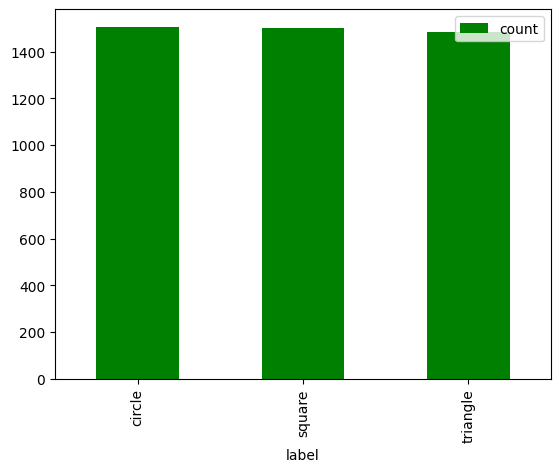

In [12]:
val_data['label'].value_counts().to_frame().plot(kind='bar', color='green')


Histograma verde (val_data)
Eje X (label):

Muestra las etiquetas de las clases:
square (cuadrado).
circle (círculo).
triangle (triángulo).S
Eje Y (count):

Indica el número de imágenes en el conjunto de validación que pertenecen a cada clase.
Características:

Las tres barras tienen aproximadamente la misma altura (~1600 imágenes por clase).
El color verde representa la distribución específica del conjunto de validación.
¿Por qué ocurre esto?

Antes de dividir los datos en entrenamiento, validación y prueba, el dataset original probablemente tenía un número igual o balanceado de imágenes por clase.
Esto asegura que cada subconjunto tenga una representación equilibrada de las clases, algo que es crucial para un entrenamiento y validación justos.


#  Histograma de las etiquetas en los conjuntos de prueba (test_data).

<Axes: xlabel='label'>

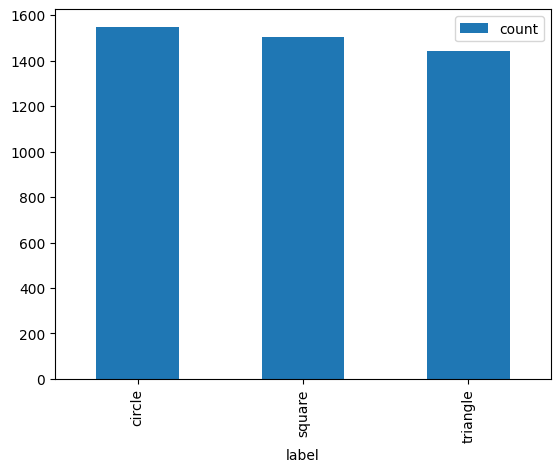

In [13]:
test_data['label'].value_counts().to_frame().plot(kind='bar')


Ejes y etiquetas:

El formato del histograma es idéntico al verde, pero representa el conjunto de prueba en lugar del conjunto de validación.
El color azul distingue esta gráfica del histograma anterior.
Características:

Las barras también son casi iguales (~1600 imágenes por clase), lo que indica que el conjunto de prueba tiene una distribución balanceada de clases.
¿Por qué ocurre esto?

La división del conjunto de datos original se realizó de manera estratificada o balanceada para garantizar que el modelo pueda evaluar su rendimiento de manera justa en las tres clases.S

De los 3 gráficos anteriores se puede observar que la distribución de datos de los rectángulos y los paralelogramos en los 3 conjuntos de entrenamiento, prueba y validación es bastante uniforme, lo que es favorable para el entrenamiento y la evaluación del modelo.

# CREACIÓN DEL VECTOR ONE-HOT

In [14]:
def label_to_onehot_vector(df):
    # Columnas correspondientes a las etiquetas
    label_columns = ['circle', 'square', 'triangle']

    # Convertir las etiquetas en vectores one-hot
    df_one_hot = pd.get_dummies(df['label'], columns=label_columns)

    # Combinar el DataFrame original con las nuevas columnas one-hot
    df = pd.concat([df, df_one_hot], axis=1)

    # Asegurar que las columnas one-hot sean de tipo entero
    df[label_columns] = df[label_columns].astype(int)

    # Mezclar aleatoriamente las filas del DataFrame
    df = df.sample(frac=1).reset_index(drop=True)

    return df


Un vector one-hot es una representación de datos categóricos en forma de un vector binario. Cada categoría posible se representa como un vector, en el que un único elemento tiene el valor 1 (indicando la presencia de esa categoría), mientras que los demás elementos tienen el valor 0.

Por ejemplo, para las etiquetas ['circle', 'square', 'triangle']:

"circle" → [1, 0, 0]
"square" → [0, 1, 0]
"triangle" → [0, 0, 1]

¿Para qué sirven los vectores one-hot?

Los vectores one-hot se utilizan para convertir datos categóricos en una forma numérica que pueda ser entendida por los modelos de aprendizaje automático. La mayoría de los modelos no pueden procesar directamente datos categóricos en forma de texto (como "circle" o "square"), por lo que deben ser transformados en números.

¿Por qué se usa en este caso?
En este caso, las etiquetas ['circle', 'square', 'triangle'] representan las clases del problema de clasificación de figuras geométricas. Usar vectores one-hot permite:

- Compatibilidad con redes neuronales:

Los modelos como redes neuronales suelen usar funciones de pérdida como la entropía cruzada categórica, que requieren que las etiquetas estén en formato one-hot.

- Entrenamiento eficiente:

Durante el entrenamiento, el modelo compara las predicciones (probabilidades asignadas a cada clase) con los vectores one-hot para calcular la pérdida y actualizar los pesos.

- Flexibilidad en el escalado:

Permite que el modelo prediga probabilidades para múltiples clases, en lugar de una etiqueta categórica única.

# VECTOR ONE-HOT EN EL CONJUNTO DE TRAIN, VAL Y TEST

In [15]:
# Convertir etiquetas en vectores one-hot para los conjuntos de entrenamiento, validación y prueba
train_data = label_to_onehot_vector(train_data)
val_data = label_to_onehot_vector(val_data)
test_data = label_to_onehot_vector(test_data)


Convierte las etiquetas de los conjuntos de entrenamiento, validación y prueba en vectores one-hot utilizando la función label_to_onehot_vector.

Convertir la columna de etiquetas en vectores one-hot, lo que ayuda a que el entrenamiento del modelo sea más preciso

In [16]:
train_data.head()

,path,label,circle,square,triangle
0,./dataset\Triangle\Triangle_06c7513c-2a89-11ea...,triangle,0,0,1
1,./dataset\Triangle\Triangle_d69a5704-2a90-11ea...,triangle,0,0,1
2,./dataset\Circle\Circle_49b226a0-2a86-11ea-812...,circle,1,0,0
3,./dataset\Triangle\Triangle_c1ae3a74-2a89-11ea...,triangle,0,0,1
4,./dataset\Square\Square_23199cdc-2a93-11ea-812...,square,0,1,0


train_data.head():

Muestra las primeras 5 filas del conjunto de entrenamiento.
Cada fila contiene:
La ruta de una imagen.
La etiqueta categórica (label).
La representación one-hot correspondiente.
Propósito: Este conjunto se utiliza para entrenar el modelo. Contiene los datos que el modelo "ve" para aprender patrones.

In [17]:
test_data.head()

,path,label,circle,square,triangle
0,./dataset\Circle\Circle_dd5faa82-2a98-11ea-812...,circle,1,0,0
1,./dataset\Circle\Circle_d31289a8-2a90-11ea-812...,circle,1,0,0
2,./dataset\Square\Square_454047f4-2a96-11ea-812...,square,0,1,0
3,./dataset\Square\Square_c073ba40-2a83-11ea-812...,square,0,1,0
4,./dataset\Square\Square_159546aa-2a99-11ea-812...,square,0,1,0


test_data.head():

Similar a train_data, pero pertenece al conjunto de prueba.
Este conjunto no se utiliza durante el entrenamiento. Se reserva para evaluar el rendimiento final del modelo después del entrenamiento.
Propósito:
Permite verificar si el modelo puede generalizar a datos que nunca ha visto.

In [18]:
val_data.head()

,path,label,circle,square,triangle
0,./dataset\Circle\Circle_4cbcb7be-2a88-11ea-812...,circle,1,0,0
1,./dataset\Circle\Circle_06c2d444-2a8a-11ea-812...,circle,1,0,0
2,./dataset\Circle\Circle_8d1392d6-2a8a-11ea-812...,circle,1,0,0
3,./dataset\Circle\Circle_26eb14ea-2a97-11ea-812...,circle,1,0,0
4,./dataset\Circle\Circle_156286dc-2a96-11ea-812...,circle,1,0,0


val_data.head():

Similar a los anteriores, pero pertenece al conjunto de validación.
Propósito:
Durante el entrenamiento, este conjunto se usa para medir el rendimiento del modelo en datos que no están directamente involucrados en el ajuste de pesos. Esto ayuda a detectar problemas como el sobreajuste.

In [4]:
# Definir las etiquetas únicas
labels = ['circle', 'square', 'triangle']

# Calcular el número total de etiquetas
num_labels = len(labels)

# Imprimir el número de etiquetas
print("Número de etiquetas:")
print(num_labels)


Número de etiquetas:
3


Define las etiquetas únicas (circle, square, triangle) y calcula su cantidad (num_labels). Imprime el número total de etiquetas.

# VISUALIZACIÓN DE ALGUNAS IMÁGENES DEL CONJUNTO DE ENTRENAMIENTO

(200, 200, 3)
(200, 200, 3)
(200, 200, 3)
(200, 200, 3)
(200, 200, 3)
(200, 200, 3)
(200, 200, 3)
(200, 200, 3)


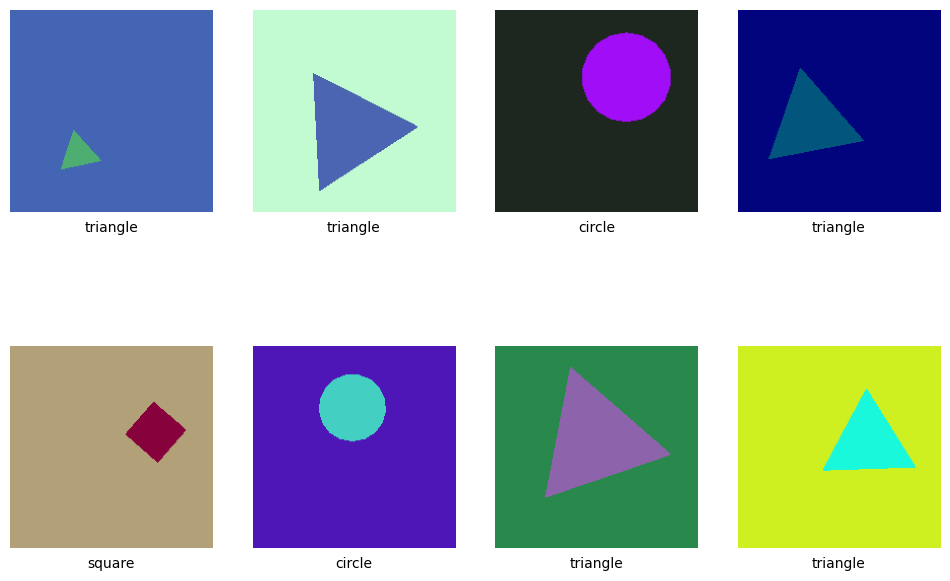

In [20]:
from PIL import Image
# Crear un grid de imágenes para visualizar ejemplos del conjunto de entrenamiento

# Número de filas y columnas en el grid
num_rows = 2
num_cols = 4

# Crear un grid de subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

for i in range(num_rows):
    for j in range(num_cols):
        index = i * num_cols + j
        if index < len(train_data):
            # Leer la imagen desde la ruta especificada
            im = Image.open(train_data.iloc[index]['path'])
            img = np.array(im)
            print(img.shape)  # Mostrar las dimensiones de la imagen

            # Mostrar la imagen en el grid
            axes[i, j].imshow(img)
            axes[i, j].axis('off')  # Desactivar los ejes

            # Mostrar la etiqueta debajo de la imagen
            label = train_data.iloc[index]['label']
            axes[i, j].text(0.5, -0.1, label, ha='center', transform=axes[i, j].transAxes)

# Mostrar el grid completo
plt.show()


El objetivo es visualizar un subconjunto de imágenes del conjunto de entrenamiento (train_data) junto con sus etiquetas.

Se crea una cuadrícula de 2 filas por 4 columnas para mostrar un total de 8 imágenes.

Cada imagen se lee desde la columna path del DataFrame train_data usando Image.open. Se convierte en un array de NumPy y se muestra en el grid.

La etiqueta de la imagen (almacenada en la columna label) se muestra debajo de cada imagen.

# NORMALIZACIÓN DE LAS IMÁGENES

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Crear generadores de datos para preprocesamiento
image_data_generator = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalizar píxeles al rango [0, 1]
)
test_data_generator = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalizar píxeles al rango [0, 1]
)


Este código utiliza ImageDataGenerator para preprocesar las imágenes antes de que sean enviadas al modelo de aprendizaje profundo. Esto es un paso importante en cualquier pipeline de entrenamiento de redes neuronales con imágenes.

Cuando tienes una imagen digital, está compuesta por una rejilla de píxeles (pequeños puntos de color). Cada píxel tiene un valor que representa su color.

En imágenes en escala de grises, cada píxel tiene un único valor que va de 0 a 255:

- 0: Negro.
- 255: Blanco.
- Valores intermedios (como 128): Grises.

ImageDataGenerator se utiliza para normalizar las imágenes. La normalización se realiza dividiendo cada valor de píxel (que originalmente está en el rango [0, 255]) entre 255 para llevarlo al rango [0, 1].

Los modelos de redes neuronales funcionan mejor cuando los valores de entrada están dentro de un rango pequeño y consistente (como [0, 1]). Esto ayuda a estabilizar el proceso de optimización y acelera la convergencia durante el entrenamiento.

Normalizar significa escalar los valores a un rango diferente. En este caso, queremos escalar los valores de píxel de 0 a 255 al rango 0 a 1.

Esto se hace dividiendo cada valor del píxel entre 255. Por ejemplo:

- Si el píxel tiene un valor de 255:  Valor Normalizado = 255/255 = 1.0
- Si el píxel tiene un valor de 128:  Valor Normalizado = 128/255 ≈ 0.502
- Si el píxel tiene un valor de 0:  Valor Normalizado = 0/255 = 0.0


En definitiva, se normaliza las imágenes para asegurarse de que los valores de píxel estén en el rango [0, 1]. Este es un paso esencial para que el modelo de aprendizaje profundo funcione de manera eficiente y precisa tanto durante el entrenamiento como durante la evaluación

# CREACIÓN DE GENERADORES

In [ ]:

# Crear generadores para entrenamiento, validación y prueba

# Generador para el conjunto de entrenamiento
train_generator = image_data_generator.flow_from_dataframe(
    dataframe=train_data,      # DataFrame de datos de entrenamiento
    x_col="path",              # Columna con rutas de imágenes
    y_col=labels,              # Columnas con etiquetas (one-hot)
    batch_size=32,             # Tamaño del lote
    shuffle=True,              # Mezclar los datos
    class_mode="raw",          # Usar etiquetas en formato raw (one-hot)
    target_size=(224, 224),    # Redimensionar las imágenes a 224x224 píxeles
)

# Generador para el conjunto de validación
val_generator = image_data_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col="path",
    y_col=labels,
    batch_size=32,
    shuffle=True,
    class_mode="raw",
    target_size=(224, 224),
)

# Generador para el conjunto de prueba
test_generator = test_data_generator.flow_from_dataframe(
    dataframe=test_data,
    x_col="path",
    y_col=labels,
    batch_size=32,
    shuffle=True,
    class_mode="raw",
    target_size=(224, 224),
)


Found 20979 validated image filenames.
Found 4495 validated image filenames.
Found 4496 validated image filenames.


20979

El código presentado utiliza generadores para procesar imágenes y proporcionar lotes de datos (batches) al modelo durante el entrenamiento, validación y prueba.

Un generador es una herramienta que permite cargar y procesar datos de manera eficiente, entregándolos al modelo en pequeños lotes (batches), en lugar de cargar todos los datos en la memoria al mismo tiempo.

En este caso, los generadores se crean con la función flow_from_dataframe de Keras, que:

- Lee los datos desde un DataFrame que contiene rutas de imágenes y sus etiquetas.
- Preprocesa las imágenes.
- Proporciona los datos al modelo en lotes pequeños para que puedan ser manejados eficientemente.

¿Por qué se utilizan generadores en este proyecto?

- Si tienes un conjunto de datos muy grande, cargar todas las imágenes en la memoria puede ser imposible o muy ineficiente. Los generadores cargan y procesan imágenes solo cuando son necesarias, lo que reduce el uso de memoria.

- Los generadores permiten aplicar transformaciones como normalización y redimensionamiento en cada lote de datos. Esto asegura que el modelo reciba datos correctamente preprocesados.

- Los generadores proporcionan los datos de manera continua durante el entrenamiento, sin necesidad de cargar todo el conjunto de datos de una vez.

- dataframe=train_data: Proporciona los datos de entrenamiento desde un DataFrame que contiene las rutas (path) y etiquetas (labels).
- x_col="path": Define la columna que contiene las rutas de las imágenes.
- y_col=labels: Define las columnas que contienen las etiquetas de las clases en formato one-hot.
- batch_size=32: Las imágenes se cargan en lotes de 32.
- shuffle=True: Mezcla los datos en cada epoch para evitar que el modelo aprenda patrones no deseados debido al orden de los datos.
- class_mode="raw": Las etiquetas se mantienen en su formato original (matriz one-hot).
- target_size=(224, 224): Todas las imágenes se redimensionan a 224x224 píxeles para que coincidan con la entrada del modelo.

En definiitva:

- Las imágenes se cargan en pequeños lotes, permitiendo trabajar con grandes conjuntos de datos sin saturar la memoria.
- Se normaliza los valores de píxeles al rango [0, 1].
- Se edimensiona todas las imágenes a 224x224 píxeles, asegurando que el modelo reciba entradas consistentes.
- Proporciona generadores separados para entrenamiento, validación y prueba, lo que garantiza que los datos no se mezclen y que los resultados sean representativos.

Tener generadores independientes para los conjuntos de entrenamiento, validación y prueba permite preprocesar cada conjunto de datos de manera uniforme pero separada. Esto asegura que los datos de prueba y validación no se mezclen con los datos de entrenamiento.

In [26]:

# Mostrar el número total de imágenes en el conjunto de entrenamiento
train_generator.n

20979

# CREACIÓN DE CALLBACKS PARA EL PROCESO DE ENTRENAMIENTO

In [42]:
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

# Definir función para crear callbacks
def call_back(checkpoint_path):
    # Callback para detener el entrenamiento si no mejora después de 10 epochs
    early_stopping_callback = EarlyStopping(
        patience=3,                  # Número de epochs sin mejora antes de detener
        monitor="val_loss",           # Monitorear la pérdida de validación
        restore_best_weights=True,    # Restaurar los mejores pesos
        verbose=1,
    )

    # Callback para guardar el modelo en su mejor estado
    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,     # Ruta para guardar el modelo
        save_weights_only=True,       # Guardar solo los pesos del modelo
        monitor="val_loss",           # Monitorear la pérdida de validación
        save_best_only=True,          # Guardar solo si es el mejor modelo
        mode="min",                   # Monitorear valores mínimos de "val_loss"
        verbose=1,
    )

    return early_stopping_callback, checkpoint_callback

En el contexto de redes neuronales y Keras, un callback es un conjunto de funciones que se ejecutan automáticamente en puntos específicos del proceso de entrenamiento.

Los callbacks permiten realizar tareas como:

- Guardar el modelo en su mejor estado.
- Detener el entrenamiento si no hay mejoras.
- Ajustar hiperparámetros dinámicamente.

Aquí, se implementa dos callbacks importantes: EarlyStopping y ModelCheckpoint, que se utilizan para mejorar y controlar el proceso de entrenamiento.

Los parámetros establecidos para EarlyStopping son:

- patience=3:

Si la pérdida de validación (val_loss) no mejora en 3 epochs consecutivas, se detiene el entrenamiento. Esto evita gastar tiempo computacional en epochs adicionales que no aporten mejoras.

La pérdida de validación indica qué tan bien el modelo generaliza a datos no vistos.

- monitor="val_loss":

Monitorea la métrica val_loss (pérdida en el conjunto de validación) como indicador del rendimiento del modelo.

- restore_best_weights=True:

Al finalizar el entrenamiento, se restauran los pesos del modelo correspondientes a la epoch con el menor val_loss. Esto asegura que el modelo guardado sea el mejor logrado durante el entrenamiento.

- verbose=1:

Muestra mensajes en la consola sobre cuándo se detiene el entrenamiento y por qué.

Los parámetros establecidos para ModelCheckpoint son:

. filepath=checkpoint_path:

Define la ruta donde se guardarán los pesos del modelo. En este caso, se guardarán en ./model_saver/tinyCNN.weights.h5.

- save_weights_only=True:

Guarda únicamente los pesos del modelo, no la arquitectura completa. Esto ocupa menos espacio y es útil si se sabe que la arquitectura no cambiará.

- monitor="val_loss":

Monitorea la métrica val_loss para decidir si se debe guardar el modelo.

- save_best_only=True:

Solo guarda el modelo si logra una mejor métrica (menor val_loss) que los modelos anteriores.

- mode="min":

Busca minimizar la métrica monitoreada (val_loss). Si quisieras maximizar una métrica, como la precisión (accuracy), usarías mode="max".

- verbose=1:

Muestra mensajes en la consola cada vez que el modelo se guarda, indicando la mejora en la métrica.



El uso de los callbacks EarlyStopping y ModelCheckpoint en el proyecto de clasificación de figuras geométricas (círculo, cuadrado o triángulo) tiene las siguientes finalidades:

EarlyStopping: Detiene el entrenamiento si la pérdida de validación (val_loss) no mejora después de 3 epochs.

ModelCheckpoint: Guarda los mejores pesos del modelo basado en el menor valor de val_loss.

Propósito de EarlyStopping:

- Detener el entrenamiento cuando el modelo deja de mejorar:

El entrenamiento de redes neuronales puede continuar durante muchas épocas (epochs), pero a partir de cierto punto, el modelo puede dejar de mejorar su rendimiento sobre los datos de validación (indicador clave de generalización).
EarlyStopping monitorea la pérdida en el conjunto de validación (val_loss) y detiene el entrenamiento si no hay mejoras después de un número definido de épocas (en este caso, 3).

- Evitar el sobreajuste (overfitting):

Al detener el entrenamiento cuando el modelo deja de mejorar, se evita que aprenda patrones específicos de los datos de entrenamiento que no generalizan bien en los datos de prueba.

Propósito de ModelCheckpoint

- Guardar los mejores pesos del modelo:

Durante el entrenamiento, ModelCheckpoint guarda los pesos del modelo cada vez que se alcanza un nuevo mínimo en la pérdida de validación (val_loss).
Esto asegura que incluso si el entrenamiento continúa más allá del punto óptimo, los mejores pesos se conservan.

- Facilitar la reutilización del modelo:

Al guardar los mejores pesos en un archivo, el modelo puede ser cargado posteriormente para realizar predicciones o continuar con el entrenamiento.

¿Por qué se hace esto en este proyecto específico?

En un proyecto de clasificación, como este, donde las figuras deben ser identificadas correctamente, es crucial que el modelo generalice bien y no memorize los datos de entrenamiento.

Los callbacks aseguran que el modelo alcance el mejor rendimiento posible en el conjunto de validación, lo que generalmente se traduce en un mejor rendimiento en los datos de prueba.

In [43]:
import os

# Crear la carpeta para guardar el modelo si no existe
os.makedirs("./model_saver", exist_ok=True)

# Definir ruta para guardar los pesos del modelo
checkpoint_path = "./model_saver/tinyCNN.weights.h5"

# Crear los callbacks
early_stopping_callback, checkpoint_callback = call_back(checkpoint_path)


Este código tiene como propósito preparar el entorno para guardar el modelo o sus pesos durante el entrenamiento. Esto es útil para asegurarte de que puedes recuperar el modelo o sus mejores pesos más adelante, sin necesidad de entrenarlo nuevamente desde cero.

Guardar los pesos permite que el modelo recupere su estado entrenado y continúe desde donde se dejó en caso de interrupciones.
También se utiliza para guardar los pesos del modelo que tuvo el mejor rendimiento durante el entrenamiento.

- Pesos del modelo (tinyCNN.weights.h5):

Contienen los parámetros aprendidos por el modelo durante el entrenamiento, como los valores de los filtros en las capas convolucionales y las conexiones en las capas densas.

El archivo tinyCNN.weights.h5 contendrá los pesos correspondientes al mejor desempeño en el conjunto de validación, lo que es crucial para evaluación o predicción.
Ahorrar tiempo:

Si el entrenamiento se interrumpe, puedes cargar los pesos guardados para continuar desde donde se quedó.

# CREACIÓN DEL MODELO USANDO UNA RED NEURONAL CONVOLUCIONAL CNN

In [44]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Crear el modelo secuencial
model = Sequential()

# Definir la entrada explícitamente
model.add(Input(shape=(224, 224, 3)))

# Añadir capas convolucionales y de pooling
# Primera capa convolucional: 32 filtros, kernel 3x3, activación ReLU
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Segunda capa convolucional: 64 filtros
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Tercera capa convolucional: 128 filtros
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanar las características extraídas
model.add(Flatten())

# Añadir una capa completamente conectada (densa)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Dropout para evitar sobreajuste

# Capa de salida con activación softmax para clasificación
model.add(Dense(num_labels, activation='softmax'))

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Mostrar el resumen de la arquitectura del modelo
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

# OUTPUT 

- Estructura de la tabla:

La tabla muestra la arquitectura de una red neuronal convolucional (CNN). Cada fila corresponde a una capa de la red y contiene información sobre:

- Layer (type): Nombre y tipo de la capa.
- Output Shape: Tamaño de la salida de la capa (es decir, cómo cambia la forma de los datos después de pasar por esa capa).
- Param #: Número de parámetros entrenables en esa capa.

1. conv2d_15 (Conv2D)
- Output Shape: (None, 222, 222, 32): Significa que esta capa convolucional genera 32 filtros (canales) con un tamaño espacial de 222x222.
- Param #: 896: Son los parámetros entrenables.

2. max_pooling2d_15 (MaxPooling2D)
- Output Shape: (None, 111, 111, 32): La operación de MaxPooling reduce a la mitad el tamaño espacial (de 222x222 a 111x111) mientras mantiene los 32 filtros.
- Param #: 0: El MaxPooling no tiene parámetros entrenables; solo simplifica los datos.

3. conv2d_16 (Conv2D)
- Output Shape: (None, 109, 109, 64): Esta capa genera 64 filtros, y el tamaño espacial se reduce ligeramente a 109x109 debido al padding o los ajustes en la convolución.
- Param #: 18,496.

4. max_pooling2d_16 (MaxPooling2D)
- Output Shape: (None, 54, 54, 64): El tamaño espacial vuelve a reducirse a la mitad (de 109x109 a 54x54), manteniendo los 64 filtros.
- Param #: 0: Sin parámetros entrenables.

5. conv2d_17 (Conv2D)
- Output Shape: (None, 52, 52, 128): Genera 128 filtros, con un tamaño espacial reducido a 52x52.
- Param #: 73,856: Nuevos parámetros entrenables.

6. max_pooling2d_17 (MaxPooling2D)
- Output Shape: (None, 26, 26, 128): Reduce el tamaño espacial a 26x26, manteniendo 128 filtros.
- Param #: 0: Sin parámetros entrenables.

7. flatten_5 (Flatten)
- Output Shape: (None, 86528): Convierte el volumen 3D (26x26x128) en un vector 1D de tamaño 86,528.
- Param #: 0: No tiene parámetros entrenables, solo transforma la forma de los datos.

8. dense_10 (Dense)
- Output Shape: (None, 256): Es una capa densa (fully connected) con 256 neuronas.
- Param #: 22,151,424: Estos son los pesos que conectan las 86,528 entradas con las 256 salidas.

9. dropout_5 (Dropout)
- Output Shape: (None, 256): Aplica la técnica de Dropout, desactivando aleatoriamente conexiones.
- Param #: 0: No tiene parámetros entrenables.

10. dense_11 (Dense)
- Output Shape: (None, 3): Es la última capa densa con 3 salidas, que  corresponden a las clases del problema ( "círculo", "triángulo", "cuadrado").
- Param #: 771: Son los pesos que conectan las 256 entradas con las 3 salidas.


Los 22,245,443 parámetros son los valores que el modelo aprende durante el entrenamiento para realizar esta clasificación de manera precisa.

# EXPLICACIÓN DEL MODELO

Este modelo está diseñado utilizando redes neuronales convolucionales (CNN) para diferenciar imágenes en tres categorías: círculos, cuadrados y triángulos.

Una CNN (Convolutional Neural Network) es un tipo de red neuronal diseñada para trabajar con datos espaciales, como imágenes. Se utiliza aquí porque:

Las CNN pueden detectar patrones espaciales, como bordes, esquinas y formas, lo cual es esencial para reconocer figuras geométricas.
Filtran y reducen datos progresivamente, aprendiendo representaciones más abstractas (de bordes simples a formas completas).

La creación del modelo comienza con la creación de un modelo secuencial, que permite apilar capas de manera lineal, facilitando la construcción de la arquitectura con model = Sequencial().

Luego, con model.add(Input(shape=(224, 224, 3)))  se define el tamaño de entrada como una imagen de 224x224 píxeles con 3 canales (RGB) ( RED, GREEN, BLUE). Esto asegura que todas las imágenes procesadas tengan un tamaño uniforme.


El output  muestra el resumen de la arquitectura del modelo que se ha construido. Este resumen incluye detalles clave sobre cada capa de la red neuronal convolucional (CNN) y confirma que tu modelo está configurado correctamente.

El modelo tiene un total de 22,245,443 parámetros que serán ajustados durante el entrenamiento.

## Elección de las capas que se aplican al proyecto

Determinar qué capas incluir en un modelo de CNN, cuántas usar, y cómo configurarlas es un proceso que combina principios básicos, experiencia previa, y experimentación práctica. 

No existe una regla única que funcione para todos los problemas, pero para este proyecto te explicamos cómo y por qué se decidió esta arquitectura.

El diseño del modelo depende de varios factores clave:

1. Naturaleza del problema
En este caso, necesitas clasificar imágenes simples (círculos, cuadrados, triángulos). Esto influye en:

Complejidad del modelo:

- Las figuras geométricas son patrones relativamente simples, por lo que no necesitas un modelo extremadamente complejo.
- Modelos más grandes (más capas y filtros) podrían ser innecesarios y propensos al sobreajuste.

Dimensiones de las imágenes:

- Se trabaja con imágenes de 224x224 píxeles y 3 canales (RGB). Este tamaño es estándar en muchos proyectos, por lo que es una buena elección inicial.



## Capas convolucionales (Conv2D)


Estas capas detectan características espaciales de las imágenes (bordes, texturas, patrones) mediante filtros.

¿Cuántas capas convolucionales usar?

En este modelo, se usaron 3 capas convolucionales, que es un número razonable para datos visuales simples como figuras geométricas.
Más capas permitirían detectar patrones más complejos, pero eso no es necesario en este caso porque las formas son bastante simples (líneas rectas, bordes, curvas).

¿Cómo determinamos los filtros y el tamaño del kernel?

Número de filtros:

- Aumenta gradualmente (32 → 64 → 128):
- Las primeras capas detectan características simples (bordes, esquinas).
- Las capas posteriores combinan esas características simples para detectar patrones más abstractos.
- Aumentar más los filtros podría ser innecesario y consumiría más recursos computacionales.

Tamaño del kernel:

- El kernel (3, 3) es una elección estándar que funciona bien en la mayoría de los casos.
- Un kernel más grande (por ejemplo, (5, 5)) capturaría más contexto, pero perdería detalles locales importantes.

EXPLICACIÓN DEL CODIGO:

model.add(Conv2D(32, (3, 3), activation='relu')):

- Conv2D aplica filtros sobre las imágenes para detectar patrones como bordes y texturas.

- Filtros: Cada capa tiene filtros (kernels) que se mueven sobre la imagen para extraer características:
32 filtros en la primera capa: Detecta patrones simples (bordes, líneas).
64 filtros en la segunda capa: Aprende combinaciones de patrones simples.
128 filtros en la tercera capa: Detecta estructuras más complejas, como formas.

Los filtros ayudan al modelo a identificar características clave en las imágenes, como los bordes curvos de un círculo o las esquinas de un cuadrado.

- Kernel (3x3): Cada filtro es una pequeña ventana de 3x3 píxeles que analiza la imagen.

- ReLU (Rectified Linear Unit): 

Es la función de activación que convierte valores negativos a 0, manteniendo solo los positivos. Introduce no linealidad, permitiendo que el modelo aprenda patrones complejos.


## Capas de pooling (MaxPooling2D)


¿Por qué usar pooling y cuántas capas?

- Propósito:Reducir la resolución espacial (dimensiones de la imagen) para disminuir la carga computacional.
- Conservar las características más importantes (por ejemplo, bordes y esquinas más relevantes).

Número de capas:

- Cada capa de pooling reduce a la mitad las dimensiones espaciales.
- En este modelo, se usaron 3 capas de pooling, lo cual es suficiente para reducir las dimensiones de una imagen de 224x224 a algo manejable (26x26 después de la última capa de pooling).

EXPLICACIÓN DEL CODIGO:

model.add(MaxPooling2D(pool_size=(2, 2))):

MaxPooling2D reduce el tamaño de las características detectadas seleccionando el valor máximo en cada región de 2x2 píxeles (definida por pool_size=(2, 2)).

Reduce la resolución de las características mientras conserva la información más importante, es decir, se conservan las características más fuertes (bordes prominentes, esquinas claras) y se descartan las menos relevantes.

Esto ayuda a Reducir la complejidad computacional y Evitar el sobreajuste al condensar las características.

## Capas de aplanamiento (Flatten)

Cuando una imagen pasa por las capas convolucionales y de pooling:

- Las capas convolucionales detectan patrones como bordes, formas o texturas.
- Las capas de pooling reducen el tamaño de los datos mientras mantienen las características importantes.

Al final de estas capas, la salida de la red no es una imagen normal, sino una estructura tridimensional (3D) con las siguientes dimensiones:

- Altura (alto): Cuántos píxeles quedan verticalmente.
- Anchura (ancho): Cuántos píxeles quedan horizontalmente.
- Canales (o filtros): Cuántos filtros usaste para detectar diferentes características en la imagen.

Las capas densas (que vienen después de las convolucionales) no entienden datos en 3D.
Ellas esperan recibir un vector unidimensional (1D), como una lista de números, no un bloque 3D.

Aquí es donde entra la capa Flatten. Su trabajo es simplemente aplanar la salida 3D en una lista larga de números (vector 1D).

1. Transforma la salida 3D en un vector 1D:

Las capas convolucionales y de pooling producen salidas en formato tridimensional (alto, ancho, número de canales o filtros). Por ejemplo, después de las últimas capas de pooling, la salida podría tener una forma como (26, 26, 128).

Esto significa:

26 x 26 es el tamaño espacial (alto y ancho) de las características detectadas.
128 son los canales o filtros, cada uno representando una característica específica.
La capa de aplanamiento convierte esta salida tridimensional en un vector unidimensional (1D). En el ejemplo anterior:

(26, 26, 128) → 26 × 26 × 128 = 86,528.

La salida de la capa Flatten sería un vector de tamaño 86,528.

Queremos pasar de :

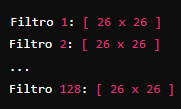

a esto:

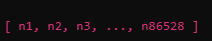

2. Prepara los datos para las capas densas:

Las capas densas esperan recibir entradas en formato 1D (vectores), no en formato tridimensional.
Sin Flatten, las capas densas no podrían procesar directamente la salida de las capas convolucionales y de pooling.

¿Por qué necesitamos aplanar los datos?

Las capas convolucionales y de pooling son excelentes para extraer características locales y espaciales de las imágenes, pero las capas densas son necesarias para:

- Combinar las características aprendidas:
Las capas densas usan el vector aplanado para aprender combinaciones más complejas y tomar decisiones.
- Clasificar las imágenes:
En este caso, queremos que las capas densas asignen probabilidades a las clases: círculo, cuadrado o triángulo.
Sin aplanar los datos, no podríamos conectar las capas convolucionales con las densas.

model.add(Flatten()): 

- Convierte la salida 3D de las capas convolucionales y de pooling en un vector 1D.
- Este vector sirve como entrada para las capas densas que seguirán.
- Propósito: Facilitar la conexión con las capas completamente conectadas.

## Capas densas ( Dense)

¿Por qué usamos capas densas después de convolucionales?

- Las capas densas conectan todas las características aprendidas por las capas convolucionales y las combinan para tomar decisiones finales.

En este modelo:

- Primera capa densa: 256 neuronas para combinar las características detectadas.
- Capa de salida: 3 neuronas (una para cada clase: círculo, cuadrado y triángulo), con activación softmax para convertir las salidas en probabilidades.

¿Por qué solo 1 capa densa antes de la salida?

- Dado que este problema es relativamente simple, una sola capa densa es suficiente.
- Más capas densas añadirían complejidad innecesaria y aumentarían el riesgo de sobreajuste.

¿Por qué usamos 256 neuronas en la primera capa densa?

La elección del número de neuronas en una capa densa es flexible y depende del nivel de complejidad del problema que queremos resolver. En este caso:

¿Qué hace esta capa?

La primera capa densa toma el vector aplanado (proveniente de las capas convolucionales) y aprende a combinar esas características para distinguir las clases (círculo, cuadrado y triángulo).

Las capas convolucionales extraen características relevantes, como bordes, formas, y texturas. La capa densa se encarga de usar esa información para aprender patrones más complejos.

¿Por qué 256?

Es un número arbitrario pero razonable para este problema:
256 neuronas son suficientes para capturar combinaciones significativas de características extraídas por las capas convolucionales. Más neuronas (por ejemplo, 512 o 1024) podrían capturar más combinaciones, pero aumentarían la complejidad del modelo y el riesgo de sobreajuste. Menos neuronas (por ejemplo, 64 o 128) podrían no ser suficientes para captar la diversidad de características necesarias para distinguir las formas.

El número de neuronas se suele reducir gradualmente en las capas densas para simplificar la información.

¿Por qué usamos 3 neuronas en la capa de salida?

La capa de salida siempre tiene tantas neuronas como clases que quieras predecir. En este caso:

Queremos clasificar entre 3 clases: círculo, cuadrado y triángulo.
Por lo tanto, necesitamos 3 neuronas, una para cada clase.

¿Qué hacen estas neuronas?

Cada neurona representa una clase específica. La salida de cada neurona es una probabilidad (usando la activación softmax), indicando cuán probable es que la imagen pertenezca a esa clase.

EXPLICACIÓN DEL CÓDIGO:

model.add(Dense(256, activation='relu')):

Primera capa densa:

- Tiene 256 neuronas que aprenden combinaciones de las características extraídas por las capas convolucionales.
- Usa ReLU como función de activación para capturar relaciones no lineales.

model.add(Dense(num_labels, activation='softmax')):

Capa de salida:

- Tiene un número de neuronas igual al número de clases (num_labels=3 en este caso).
- Usa softmax como función de activación para convertir las salidas en probabilidades, asignando cada imagen a una de las clases (círculo, cuadrado o triángulo).


## Dropout

model.add(Dropout(0.5)):

Evita el sobreajuste. Durante el entrenamiento, Dropout desactiva aleatoriamente el 50% de las conexiones en esta capa, forzando al modelo a ser más robusto.

El Dropout es una técnica usada en redes neuronales para evitar el sobreajuste.
Sobreajuste ocurre cuando el modelo aprende demasiado bien los detalles del conjunto de entrenamiento, pero no puede generalizar bien a datos nuevos

El Dropout "desactiva" aleatoriamente algunas neuronas durante el entrenamiento para que la red no dependa demasiado de ninguna de ellas.
Supongamos que tienes una red con varias neuronas en una capa:

Cuando aplicas Dropout (por ejemplo, al 50%), la mitad de esas neuronas se desactivan aleatoriamente en cada iteración del entrenamiento.
Estas neuronas desactivadas no participan en los cálculos (es como si no existieran temporalmente).


En la siguiente iteración, se desactivan otras neuronas diferentes, también de forma aleatoria.

Al forzar a la red a entrenar sin depender de todas sus neuronas al mismo tiempo, Dropout:

Evita que la red dependa demasiado de una sola neurona o grupo de neuronas.
Hace que la red aprenda patrones más generales en lugar de simplemente memorizar los datos de entrenamiento.
Fortalece la robustez del modelo, ya que las neuronas restantes tienen que adaptarse y compartir más responsabilidad.


## Compilación del modelo

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy']):

- Optimizador (Adam):

Es un algoritmo de optimización que ajusta los pesos del modelo para minimizar el error. Combina las ventajas de otros optimizadores (SGD, RMSprop) y funciona bien en la mayoría de los casos.

- Pérdida (categorical_crossentropy):

Es la función de pérdida que mide el error para problemas de clasificación multiclase (3 clases: círculo, cuadrado, triángulo).

- Métrica (accuracy):

Evalúa la precisión del modelo durante el entrenamiento.


# ENTRENAMIENTO DEL MODELO

In [45]:
hist = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4438 - loss: 1.1074
Epoch 1: val_loss improved from inf to 0.70823, saving model to ./model_saver/tinyCNN.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 811s 1s/step - accuracy: 0.4439 - loss: 1.1072 - val_accuracy: 0.6759 - val_loss: 0.7082
Epoch 2/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7230 - loss: 0.6310
Epoch 2: val_loss improved from 0.70823 to 0.41007, saving model to ./model_saver/tinyCNN.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 854s 1s/step - accuracy: 0.7231 - loss: 0.6309 - val_accuracy: 0.8338 - val_loss: 0.4101
Epoch 3/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8539 - loss: 0.3653
Epoch 3: val_loss improved from 0.41007 to 0.30199, saving model to ./model_saver/tinyCNN.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 774s 1s/step - accuracy: 0.8539 - loss: 0.3653 - val_accuracy: 0.8836 - val_loss: 0.3020
Epoch 4/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9003 - loss: 0.2560
Epoch 4

Este método es el encargado de ajustar los parámetros (pesos y sesgos) del modelo en base a los datos proporcionados. 
El código entrena el modelo (model) con datos proporcionados por train_generator, valida su rendimiento con val_generator y utiliza dos callbacks (checkpoint_callback y early_stopping_callback) para mejorar el proceso de entrenamiento.

- train_generator:

Es el generador que proporciona las imágenes del conjunto de entrenamiento en lotes.
Cada lote contiene un subconjunto de las imágenes de entrenamiento ya preprocesadas (normalizadas).

- steps_per_epoch=len(train_generator):

Indica cuántos pasos debe ejecutar el modelo en cada epoch (época) para considerar que se han procesado todas las imágenes del conjunto de entrenamiento.
El valor suele ser igual al número de lotes en train_generator.

- epochs=20:

Especifica el número máximo de épocas que se ejecutarán durante el entrenamiento.
Una época equivale a un ciclo completo en el que el modelo procesa todos los datos de entrenamiento una vez.
En este caso, el modelo puede entrenarse hasta 20 épocas, a menos que un callback, como EarlyStopping, detenga el proceso antes.

- validation_data=val_generator:

Proporciona el conjunto de validación al modelo. Este conjunto no se utiliza para ajustar los pesos del modelo, sino para evaluar su rendimiento después de cada época.
val_generator genera lotes de datos del conjunto de validación de forma similar a train_generator.

- validation_steps=len(val_generator):

Indica cuántos pasos (lotes) deben procesarse en cada epoch para evaluar el rendimiento en el conjunto de validación.
Similar a steps_per_epoch, pero aplicado al conjunto de validación.

- callbacks=[checkpoint_callback, early_stopping_callback]:

Los callbacks son funciones que se ejecutan automáticamente durante el entrenamiento para monitorear o ajustar el proceso. Aquí se utilizan dos:

checkpoint_callback:

Guarda los pesos del modelo en la ubicación especificada si el rendimiento mejora.
Este callback asegura que los mejores pesos del modelo (en términos de pérdida de validación) se almacenen para su uso posterior.
early_stopping_callback:

Detiene el entrenamiento automáticamente si el rendimiento en el conjunto de validación no mejora después de un número predefinido de épocas (patience).
Esto evita desperdiciar tiempo en entrenar el modelo más de lo necesario.

- hist

El resultado de model.fit es un objeto History que almacena la evolución del entrenamiento. Contiene:

1. La pérdida (loss) y precisión (accuracy) para cada época.
2. Las métricas de validación (val_loss y val_accuracy).

Esto permite analizar el rendimiento del modelo después del entrenamiento.


El modelo entrenó con:

20 épocas máximas configuradas (epochs=20).
Early stopping: El callback detuvo el entrenamiento después de 13 épocas porque la métrica val_loss dejó de mejorar durante el número de épocas especificado en el parámetro patience

En cada época, las métricas accuracy, loss, val_accuracy y val_loss se calcularon para medir el rendimiento del modelo.

accuracy y loss (conjunto de entrenamiento)
accuracy:

Comienza en 0.4438 (44.38%) en la primera época y alcanza 0.9932 (99.32%) en la última época.
Esto indica que el modelo aprendió bien los patrones en el conjunto de entrenamiento.
loss:

Comienza en 1.1074 (una pérdida elevada, lo cual es normal al inicio del entrenamiento) y disminuye progresivamente hasta 0.0266.
Un valor de pérdida bajo sugiere que el modelo ha minimizado los errores en el conjunto de entrenamiento.
val_accuracy y val_loss (conjunto de validación)
val_accuracy:

Comienza en 0.6759 (67.59%) y mejora progresivamente hasta 0.9626 (96.26%), lo que indica una excelente capacidad de generalización hacia los datos de validación.
val_loss:

Comienza en 0.7082 y disminuye hasta 0.1725.
Un descenso constante en val_loss muestra que el modelo es capaz de reducir los errores en datos no vistos.

En la época 13, el entrenamiento se detuvo automáticamente debido a que val_loss dejó de mejorar.

Cómo funciona EarlyStopping en este caso:
En la época 10, el modelo alcanzó el valor mínimo de val_loss: 0.15519.
Después de esto, val_loss comenzó a aumentar ligeramente, indicando que el modelo podría comenzar a sobreajustar si continuara el entrenamiento.
EarlyStopping restauró automáticamente los pesos del modelo correspondientes a la época 10 (donde se obtuvo la mejor val_loss).


Los mejores pesos del modelo se guardaron en el archivo tinyCNN.weights.h5 durante el entrenamiento, cada vez que val_loss mejoraba.
En la época 10, se guardaron los últimos pesos óptimos, que serán restaurados por EarlyStopping.



# GRÁFICA PARA VER EL ACCURACY Y EL LOSS EN EL ENTRENAMIENTO Y VALIDATION

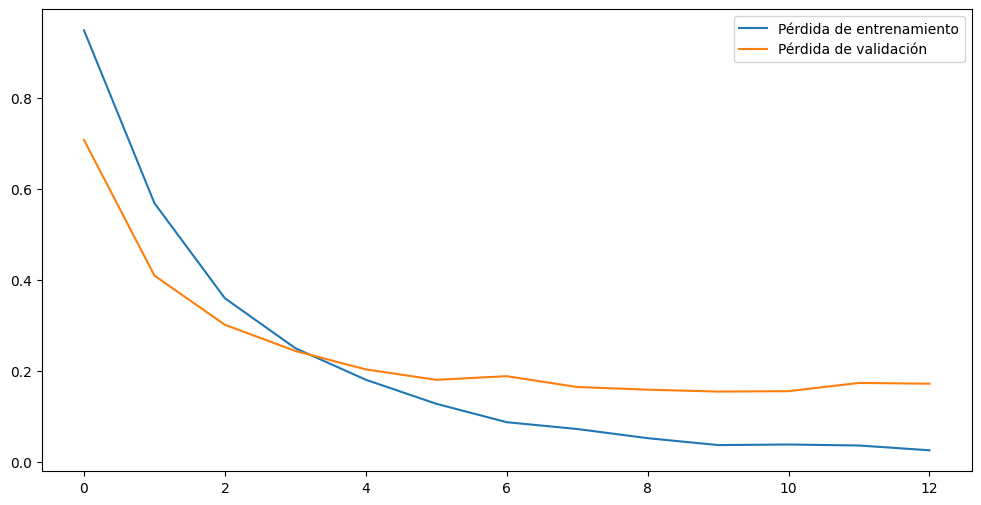

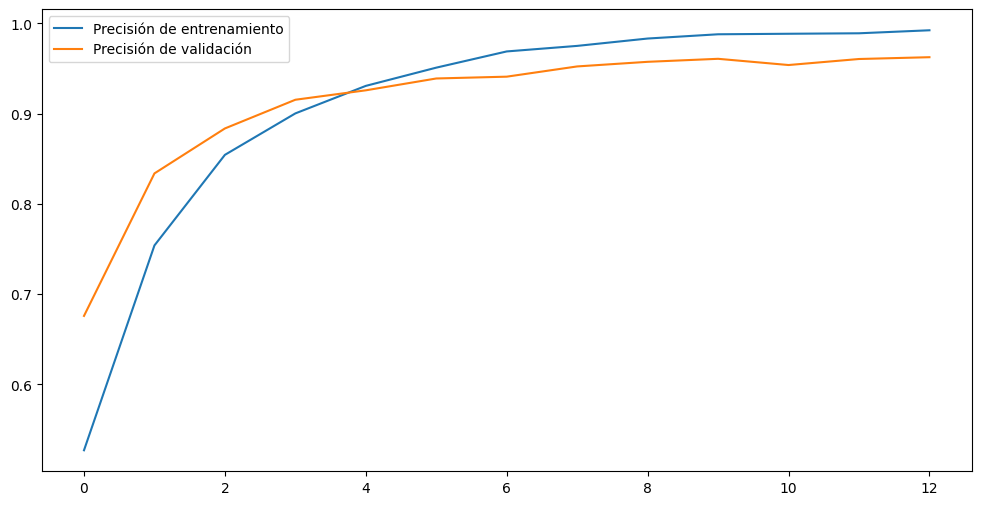

In [46]:
# Graficar pérdida durante el entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(hist.history["loss"], label="Pérdida de entrenamiento")
plt.plot(hist.history["val_loss"], label="Pérdida de validación")
plt.legend()
plt.show()

# Graficar precisión durante el entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(hist.history["accuracy"], label="Precisión de entrenamiento")
plt.plot(hist.history["val_accuracy"], label="Precisión de validación")
plt.legend()
plt.show()


Los gráficos muestran cómo evoluciona el modelo durante el entrenamiento.

- Gráfica de pérdida (entrenamiento y validación)

Eje X (horizontal): Representa las épocas (iteraciones completas sobre el conjunto de datos).
Eje Y (vertical): Representa la pérdida calculada con la función de pérdida (loss) tanto para entrenamiento como para validación.
Línea azul: Pérdida en el conjunto de entrenamiento.
Línea naranja: Pérdida en el conjunto de validación.
Interpretación:
Inicio del entrenamiento (Época 0 a 4):

Ambas pérdidas disminuyen rápidamente, lo que indica que el modelo está aprendiendo los patrones básicos de los datos.
La pérdida de validación es un poco más baja que la de entrenamiento, lo cual es normal y puede significar que el conjunto de validación es más "simple" o representativo.
Mitad del entrenamiento (Época 5 a 10):

La pérdida en ambos conjuntos continúa disminuyendo, pero de forma más lenta. Esto es una señal de que el modelo está convergiendo hacia un mínimo.
Últimas épocas (Época 10 en adelante):

La pérdida de entrenamiento sigue disminuyendo, mientras que la pérdida de validación se estabiliza.
Este patrón puede indicar que el modelo ha alcanzado su mejor punto en términos de generalización y que continuar el entrenamiento podría causar sobreajuste.

- Gráfica de precisión (entrenamiento y validación)

Eje X (horizontal): Representa las épocas.
Eje Y (vertical): Representa la precisión (accuracy), es decir, el porcentaje de predicciones correctas.
Línea azul: Precisión en el conjunto de entrenamiento.
Línea naranja: Precisión en el conjunto de validación.
Interpretación:
Inicio del entrenamiento (Época 0 a 4):

Ambas precisiones aumentan rápidamente, lo que indica que el modelo está aprendiendo a clasificar correctamente.
Mitad del entrenamiento (Época 5 a 10):

La precisión de entrenamiento sigue aumentando, mientras que la precisión de validación se estabiliza alrededor de 96%-97%.
Esto indica que el modelo generaliza bien en el conjunto de validación.
Últimas épocas (Época 10 en adelante):

La precisión de entrenamiento se acerca al 100%, mientras que la precisión de validación permanece estable.
Este comportamiento también es un signo de que el modelo ha aprendido lo suficiente y continuar podría causar sobreajuste.

# Evaluation

In [47]:
model.load_weights(checkpoint_path)  # Cargar los mejores pesos del modelo
loss, acc = model.evaluate(test_generator, steps=len(test_generator), verbose=2)

print(f"Pérdida en prueba: {loss}\nPrecisión en prueba: {acc}")


C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


141/141 - 89s - 630ms/step - accuracy: 0.9548 - loss: 0.1917
Pérdida en prueba: 0.19166553020477295
Precisión en prueba: 0.9548487663269043


- Cargar pesos:
Se cargan los mejores pesos obtenidos durante el entrenamiento.

- Evaluación:
Calcula la pérdida y precisión del modelo en el conjunto de prueba.

In [48]:
from sklearn.metrics import precision_score, recall_score, average_precision_score

true_labels = []
predicted_labels = []

# Iterar sobre los lotes del conjunto de prueba
for i in range(len(test_generator)):
    images, labels_batch = test_generator[i]
    true_labels.extend(labels_batch)

    # Realizar predicciones
    predictions = model.predict(images, verbose=0)

    # Convertir predicciones en etiquetas binarias
    binary_predictions = (predictions > 0.5).astype(int)
    predicted_labels.extend(binary_predictions)

# Convertir listas a arrays de NumPy
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Calcular métricas de precisión y recall por clase
per_class_precision = precision_score(true_labels, predicted_labels, average=None)
per_class_recall = recall_score(true_labels, predicted_labels, average=None)

# Calcular promedio de precisión (AP) por clase
ap_scores = average_precision_score(true_labels, predicted_labels, average=None)

# Calcular precisión promedio (mAP)
map_score = np.mean(ap_scores)

for label, precision, recall, ap in zip(labels, per_class_precision, per_class_recall, ap_scores):
    print(f"Etiqueta: {label}")
    print(f"Precisión: {precision}")
    print(f"Recall: {recall}")
    print(f"AP: {ap}")
    print("-" * 30)

print(f"mAP: {map_score}")


Etiqueta: circle
Precisión: 0.9765013054830287
Recall: 0.9664082687338501
AP: 0.9552647723471307
------------------------------
Etiqueta: square
Precisión: 0.9406270847231488
Recall: 0.9368770764119602
AP: 0.902381846367763
------------------------------
Etiqueta: triangle
Precisión: 0.9536973047684866
Recall: 0.9563409563409564
AP: 0.9260722480181013
------------------------------
mAP: 0.9279062889109984


Este código evalúa el rendimiento del modelo en el conjunto de prueba (test data) usando métricas de evaluación como:

- Precisión (Precision): Qué tan preciso es el modelo al clasificar correctamente una clase.
- Recall: Qué tan bien el modelo detecta todas las instancias reales de una clase.
- Promedio de Precisión (AP): Combina precisión y recall en una sola métrica por clase.
- Precisión Media Promedio (mAP): Promedia los valores de AP de todas las clases para dar una medida general del rendimiento del modelo.

El propósito principal es evaluar qué tan bien el modelo clasifica las figuras (círculos, cuadrados y triángulos) en el conjunto de prueba.

Se itera sobre el conjunto de prueba (test_generator) para obtener:

- Las etiquetas reales (labels_batch) que representan las verdaderas clases (círculo, cuadrado, triángulo).
- Las predicciones del modelo (predictions), que son probabilidades.
- Las predicciones se convierten en etiquetas binarias (binary_predictions), donde cada valor indica si una clase está presente (1) o no (0).

- precision_score:

Calcula la precisión para cada clase. Es la proporción de predicciones correctas entre todas las predicciones realizadas para esa clase.

- recall_score:

Calcula el recall para cada clase. Mide la capacidad del modelo de encontrar todos los ejemplos positivos reales.

- average_precision_score:

Calcula el promedio de precisión (AP) para cada clase, combinando precisión y recall a diferentes umbrales.

- map_score:

Promedia los valores de AP de todas las clases. Es una medida general del rendimiento del modelo.

Explicación del resultado Por clase:

- Círculo (circle):

Precisión: 0.9765 (97.65%)
De todas las imágenes clasificadas como círculos, el 97.65% son realmente círculos.
Recall: 0.9664 (96.64%)
De todas las imágenes reales de círculos, el 96.64% fueron correctamente detectadas.
AP: 0.9553 (95.53%)
Una combinación de precisión y recall.

- Cuadrado (square):

Precisión: 0.9406 (94.06%)
De todas las imágenes clasificadas como cuadrados, el 94.06% son correctas.
Recall: 0.9368 (93.68%)
De todos los cuadrados reales, el modelo identificó correctamente el 93.68%.
AP: 0.9024 (90.24%)
Una métrica combinada de precisión y recall.

- Triángulo (triangle):

Precisión: 0.9537 (95.37%)
De todas las imágenes clasificadas como triángulos, el 95.37% son correctas.
Recall: 0.9563 (95.63%)
De todos los triángulos reales, el modelo identificó correctamente el 95.63%.
AP: 0.9261 (92.61%)
Métrica combinada de precisión y recall.

- Global:

mAP = 0.9279 (92.79%):
Es el promedio de los valores de AP para todas las clases.
Representa la capacidad general del modelo para clasificar correctamente las imágenes de prueba.

- Conclusión

La precisión y el recall por clase están por encima del 90%, lo que indica que el modelo clasifica correctamente la mayoría de las imágenes.

El mAP de 92.79% refleja un excelente desempeño general.

Precisión alta significa que el modelo tiene pocas clasificaciones incorrectas (bajo número de falsos positivos).

Recall alto significa que el modelo detecta correctamente la mayoría de las instancias (bajo número de falsos negativos).

Esto es crucial en tareas como clasificación de formas geométricas, donde es importante tanto minimizar errores como detectar correctamente todas las instancias.

# DEMOSTRACIONES

In [49]:
print(labels)

['circle', 'square', 'triangle']


In [50]:
def decode_predictions(predict):
    max_confidence = 0
    predicted_label = None

    for i in range(len(predict[0])):
        if predict[0][i] > max_confidence:
            max_confidence = predict[0][i]
            predicted_label = labels[i]

    return predicted_label, round(max_confidence, 4)

def predict_image(test_predict):
    test_predict_path = test_predict['path']
    true_label = test_predict['label']
    image = keras.preprocessing.image.load_img(test_predict_path, target_size=(224, 224))
    image = keras.preprocessing.image.img_to_array(image)
    image = image.reshape((1,) + image.shape)
    image /= 255.0
    result = model.predict(image, verbose = 0)
#     print(result)
    y_pro, confidence = decode_predictions(result)
    return y_pro, confidence
    

El propósito de este código es permitir que el modelo haga predicciones sobre una imagen individual y determinar a cuál clase pertenece (círculo, cuadrado o triángulo) junto con su nivel de confianza. Esta funcionalidad es clave para evaluar el rendimiento del modelo en ejemplos específicos o nuevas imágenes que no formen parte del conjunto de datos de prueba.

La función decode_predictions recibe como entrada un arreglo de probabilidades predict generado por el modelo, donde cada posición del arreglo representa la probabilidad asignada por el modelo a una clase específica.
Busca el índice con la mayor probabilidad (max_confidence) y lo asocia con la clase correspondiente en la lista labels.
Devuelve la clase con la mayor probabilidad (predicted_label) y su confianza (max_confidence), redondeada a 4 decimales.

Con la función predict_image, la imagen es cargada desde la ruta especificada en el diccionario test_predict y redimensionada a (224, 224) píxeles, que es el tamaño esperado por el modelo.

La imagen se convierte en un arreglo NumPy para ser procesada por el modelo.
Se cambia su forma (reshape) para añadir una dimensión adicional, ya que el modelo espera un lote (batch) de imágenes.

Los valores de los píxeles se dividen por 255 para ajustarlos al rango [0, 1]. Esto ayuda a que el modelo procese los datos de manera uniforme.

Se usa model.predict para obtener las probabilidades de que la imagen pertenezca a cada clase.

Se llama a decode_predictions para identificar la clase con mayor probabilidad y su nivel de confianza.

Se retorna la clase predicha (y_pro) y la confianza asociada (confidence).

In [51]:
predict_image(test_data.iloc[0])

('circle', np.float32(0.9999))

Significado del resultado

'circle':

Es la clase que el modelo ha predicho para la imagen de prueba.
El modelo cree que la imagen pertenece a la clase "círculo".

0.9999:

Es la confianza del modelo en esta predicción (99.99%).
Esto indica que el modelo está muy seguro de que la imagen es un círculo.

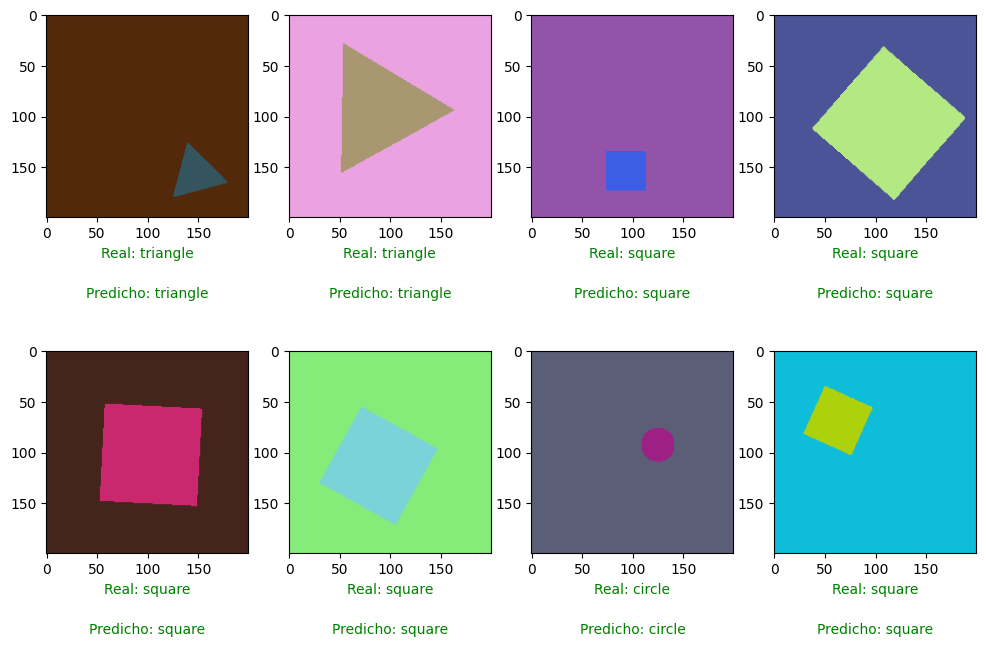

In [52]:
def plot_random_predictions(model, test_data, num_rows=2, num_cols=4):
    # Seleccionar muestras aleatorias del conjunto de prueba
    random_samples = random.sample(range(len(test_data)), num_rows * num_cols)

    # Crear un grid de subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i in range(num_rows):
        for j in range(num_cols):
            index = i * num_cols + j
            if index < len(random_samples):
                sample_index = random_samples[index]

                # Leer la imagen desde la ruta
                im = Image.open(test_data.iloc[sample_index]['path'])
                img = np.array(im)

                # Mostrar la imagen en el grid
                axes[i, j].imshow(img)

                # Mostrar la etiqueta real y predicha
                real_label = test_data.iloc[sample_index]['label']
                predicted_label, confidence = predict_image(test_data.iloc[sample_index])

                axes[i, j].text(0.5, -0.2, f'Real: {real_label}', ha='center', transform=axes[i, j].transAxes,
                                color='green' if real_label == predicted_label else 'red')

                axes[i, j].text(0.5, -0.4, f'Predicho: {predicted_label}', ha='center',
                                transform=axes[i, j].transAxes, color='green' if real_label == predicted_label else 'red')

    # Mostrar el grid de subplots
    plt.show()

# Ejecutar la visualización
plot_random_predictions(model, test_data)


Este código tiene como objetivo visualizar las predicciones del modelo sobre un conjunto de datos de prueba de manera gráfica y comprensible.

La función plot_random_predictions selecciona imágenes aleatorias del conjunto de prueba, predice sus etiquetas utilizando el modelo entrenado y las muestra en un grid. Cada imagen se acompaña de:

1. La etiqueta real (la clase verdadera de la imagen).
2. La etiqueta predicha por el modelo.
3. Indicadores visuales (colores) para señalar si la predicción es correcta o incorrecta.

Se selecciona aleatoriamente num_rows * num_cols índices de imágenes del conjunto de prueba test_data. (Por defecto, selecciona 8 imágenes (2 filas x 4 columnas)).

Luego se crea un grid de gráficos (subplots) con dimensiones num_rows x num_cols. Cada celda del grid se usará para mostrar una imagen y sus etiquetas asociadas.

Posteriormente, Recorre cada celda del grid y asigna una imagen aleatoria del conjunto de prueba y se calcula el índice de la muestra a partir de random_samples.

Para realizar la carga y procesamiento de imagenes, abre la imagen desde su ruta usando Image.open y convierte la imagen en un array de NumPy (np.array) para poder ser visualizada con imshow.

Para realizar las predicciones del modelo, obtiene la etiqueta real (real_label) de la imagen desde el DataFrame test_data y llama a la función predict_image para predecir la clase de la imagen y su nivel de confianza.

Por último, muestra la imagen en la celda correspondiente del grid.

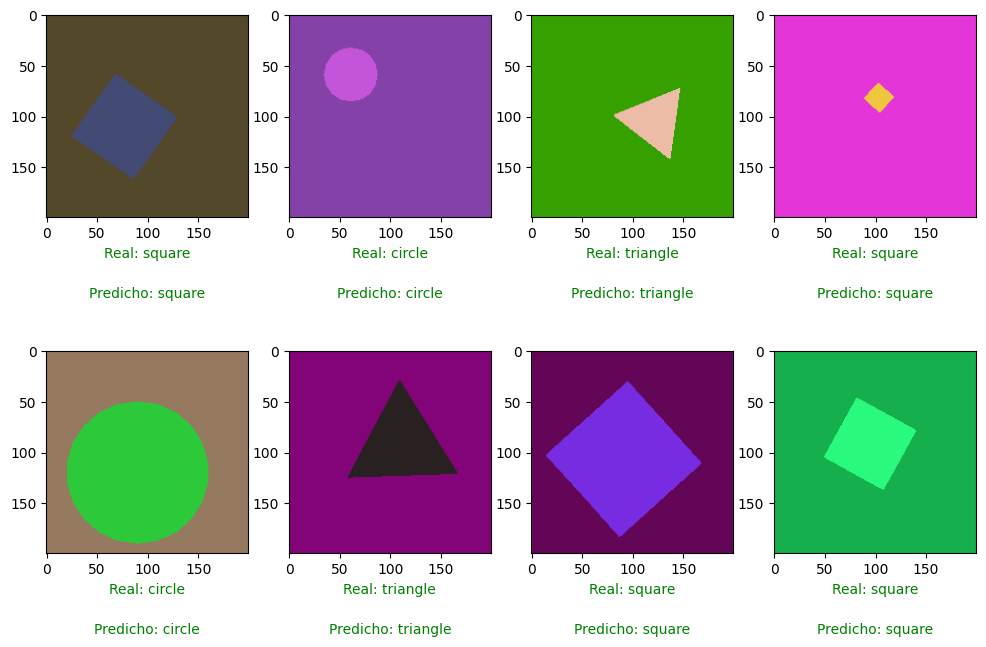

In [53]:
# Chạy hàm này nhiều lần nhé, mỗi lần nó sẽ đưa ra hình ảnh khác nhau. Nếu model đoán đúng thì có màu xanh, nếu sai có màu đỏ
plot_random_predictions(model, test_data)